In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import json
import os

# Paths
PROCESSED_PATH = "../data/processed/"
FINAL_PATH = "../data/final/"
DB_PATH = "../data/final/surf_pipeline.db"

print("✓ Libraries loaded")

✓ Libraries loaded


In [4]:
# Load cleaned buoy data
buoy_df = pd.read_csv(f"{PROCESSED_PATH}buoy_data_clean.csv")
scores_df = pd.read_csv(f"{PROCESSED_PATH}surf_scores.csv")
seismic_df = pd.read_csv(f"{PROCESSED_PATH}seismic_data_clean.csv")

print(f"Buoy records    : {len(buoy_df)}")
print(f"Surf scores     : {len(scores_df)}")
print(f"Seismic records : {len(seismic_df)}")

Buoy records    : 1292600
Surf scores     : 4
Seismic records : 1090


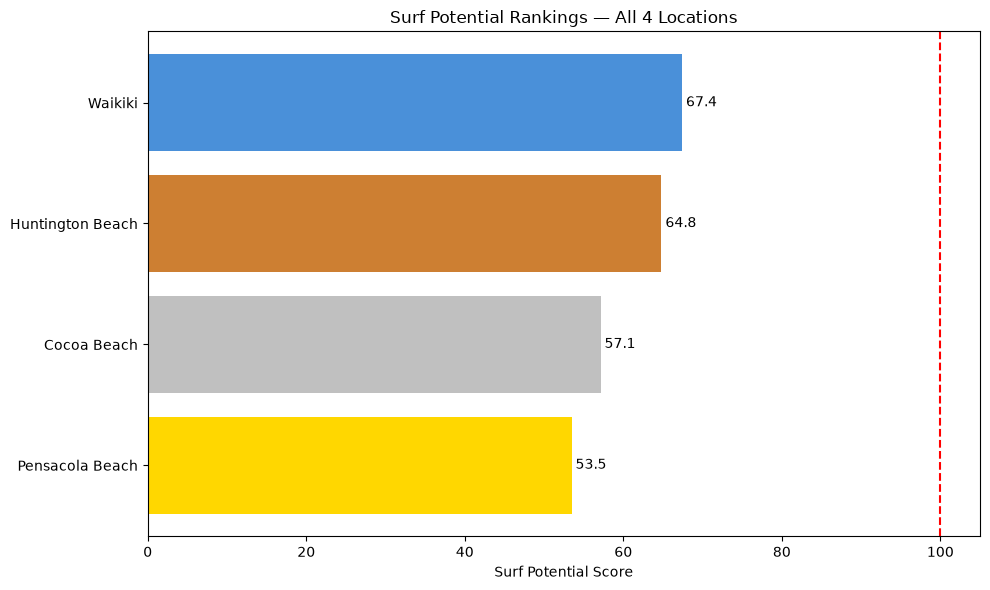

✓ Rankings chart saved


In [5]:
# Plot surf potential rankings
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["gold", "silver", "#cd7f32", "#4a90d9"]
bars = ax.barh(
    scores_df.sort_values("surf_potential_score")["location_name"],
    scores_df.sort_values("surf_potential_score")["surf_potential_score"],
    color=colors
)

ax.set_xlabel("Surf Potential Score")
ax.set_title("Surf Potential Rankings — All 4 Locations")
ax.axvline(x=100, color="red", linestyle="--", label="Nazaré Benchmark (100)")

for bar, score in zip(bars, scores_df.sort_values("surf_potential_score")["surf_potential_score"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{score:.1f}", va="center")

plt.tight_layout()
plt.savefig("surf_rankings.png")
plt.show()
print("✓ Rankings chart saved")

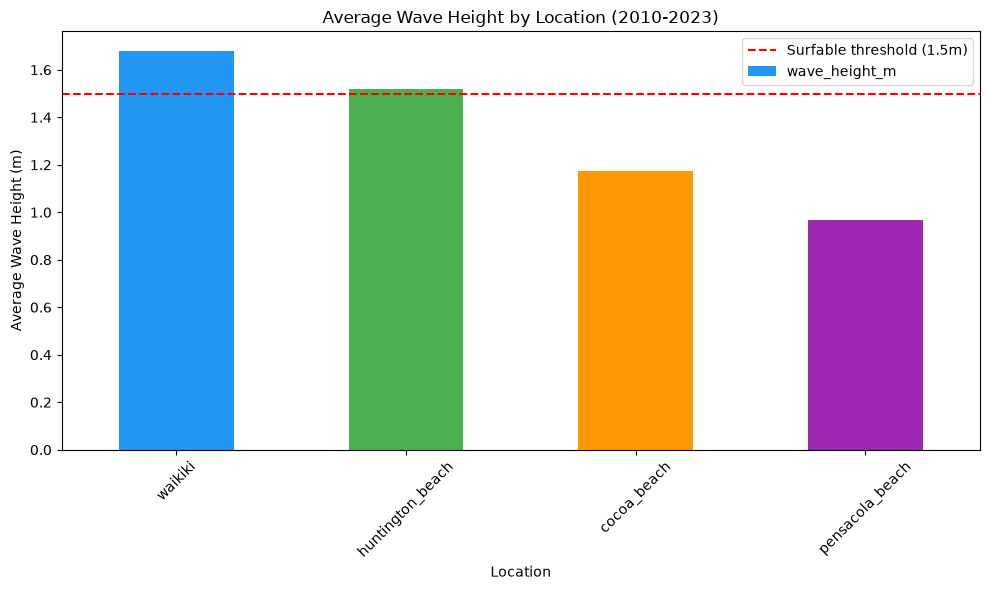

In [6]:
# Average wave height by location
avg_wave = buoy_df.groupby("location")["wave_height_m"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
avg_wave.plot(kind="bar", ax=ax, color=["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"])
ax.set_title("Average Wave Height by Location (2010-2023)")
ax.set_xlabel("Location")
ax.set_ylabel("Average Wave Height (m)")
ax.axhline(y=1.5, color="red", linestyle="--", label="Surfable threshold (1.5m)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("avg_wave_height.png")
plt.show()

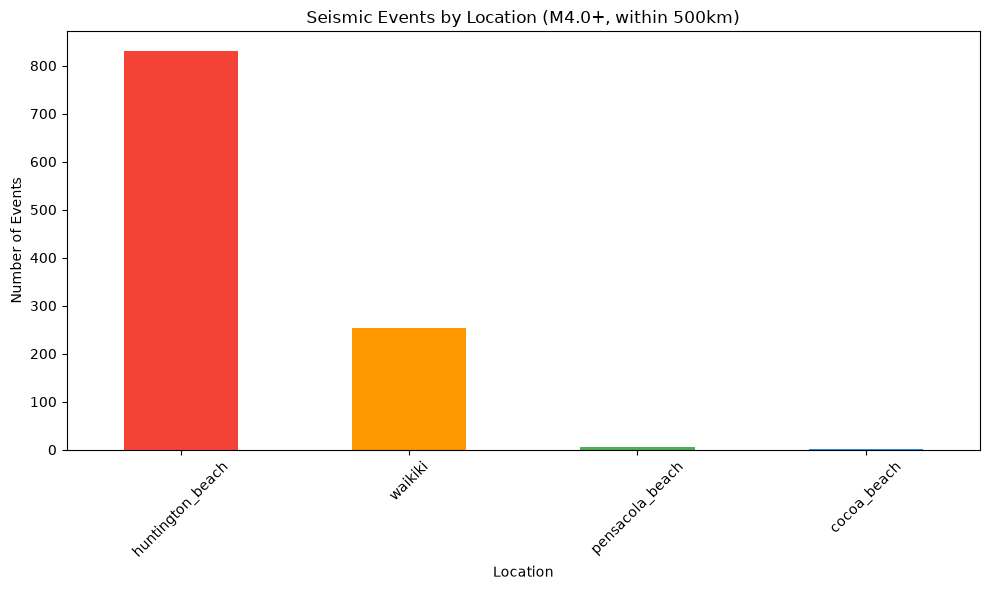

In [7]:
# Seismic events count by location
seismic_count = seismic_df.groupby("location")["magnitude"].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
seismic_count.plot(kind="bar", ax=ax, color=["#F44336", "#FF9800", "#4CAF50", "#2196F3"])
ax.set_title("Seismic Events by Location (M4.0+, within 500km)")
ax.set_xlabel("Location")
ax.set_ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("seismic_events.png")
plt.show()

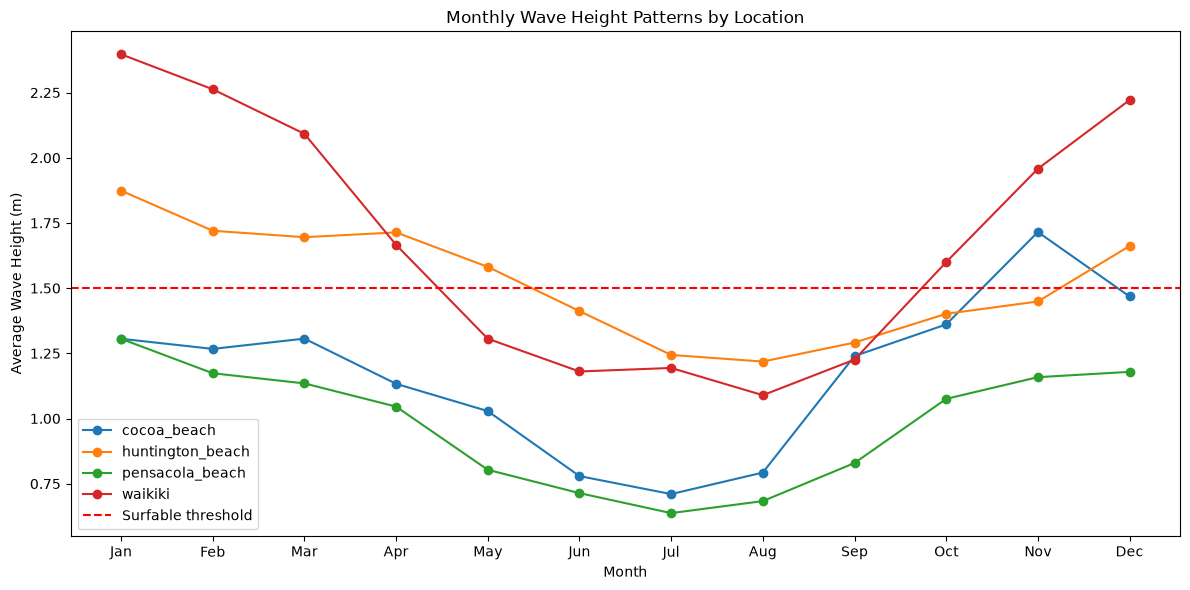

In [8]:
# Monthly average wave height per location
buoy_df_clean = buoy_df.dropna(subset=["wave_height_m"])
buoy_df_clean = buoy_df_clean[buoy_df_clean["wave_height_m"] < 30]

monthly = buoy_df_clean.groupby(["location", "month"])["wave_height_m"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

for location in monthly["location"].unique():
    loc_data = monthly[monthly["location"] == location]
    ax.plot(loc_data["month"], loc_data["wave_height_m"], marker="o", label=location)

ax.set_title("Monthly Wave Height Patterns by Location")
ax.set_xlabel("Month")
ax.set_ylabel("Average Wave Height (m)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.axhline(y=1.5, color="red", linestyle="--", label="Surfable threshold")
ax.legend()
plt.tight_layout()
plt.savefig("monthly_patterns.png")
plt.show()

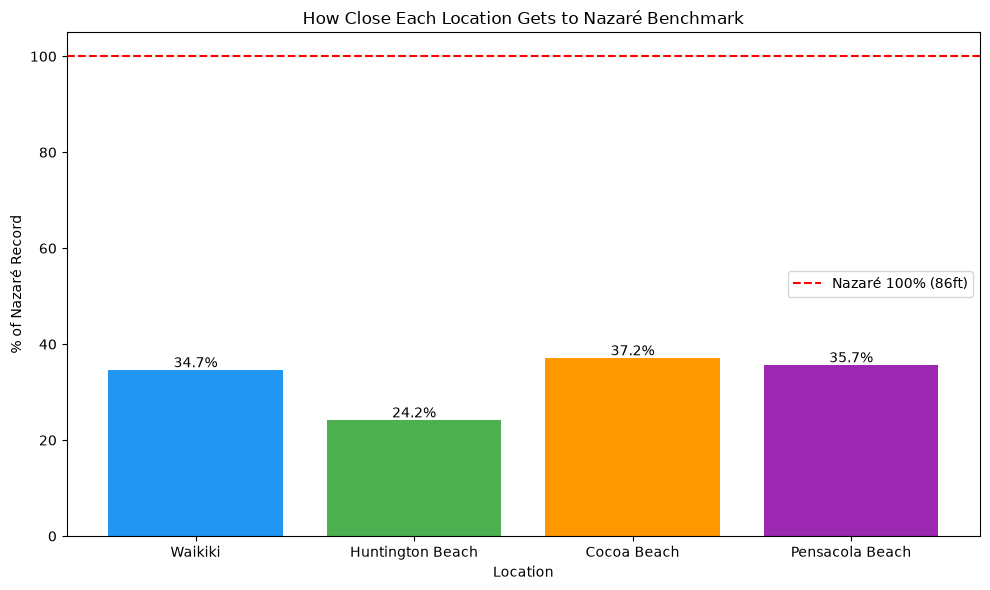

In [9]:
# How close each location gets to Nazare benchmark
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    scores_df["location_name"],
    scores_df["pct_of_nazare"],
    color=["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
)

ax.axhline(y=100, color="red", linestyle="--", label="Nazaré 100% (86ft)")
ax.set_title("How Close Each Location Gets to Nazaré Benchmark")
ax.set_xlabel("Location")
ax.set_ylabel("% of Nazaré Record")

for bar, pct in zip(bars, scores_df["pct_of_nazare"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{pct:.1f}%", ha="center")

ax.legend()
plt.tight_layout()
plt.savefig("benchmark_comparison.png")
plt.show()

In [10]:
# Final summary
print("=" * 60)
print("SURF PIPELINE — EDA SUMMARY")
print("=" * 60)
print(f"\nTotal buoy records analyzed : {len(buoy_df):,}")
print(f"Date range                  : 2010 - 2023")
print(f"Locations analyzed          : 4")
print(f"Seismic events tracked      : {len(seismic_df):,}")

print("\n--- Final Rankings ---")
for _, row in scores_df.sort_values("rank").iterrows():
    print(f"#{int(row['rank'])} {row['location_name']:<20} Score: {row['surf_potential_score']:.2f}")

print("\n--- Benchmark Reference ---")
print(f"Lituya Bay (upper bound)    : 1,720 ft (524m) — not surfable")
print(f"Nazaré (surfability ceiling): 86 ft (26.2m) — surfed by Sebastian Steudtner 2020")

SURF PIPELINE — EDA SUMMARY

Total buoy records analyzed : 1,292,600
Date range                  : 2010 - 2023
Locations analyzed          : 4
Seismic events tracked      : 1,090

--- Final Rankings ---
#1 Waikiki              Score: 67.41
#2 Huntington Beach     Score: 64.81
#3 Cocoa Beach          Score: 57.13
#4 Pensacola Beach      Score: 53.47

--- Benchmark Reference ---
Lituya Bay (upper bound)    : 1,720 ft (524m) — not surfable
Nazaré (surfability ceiling): 86 ft (26.2m) — surfed by Sebastian Steudtner 2020
